In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
data = pd.read_csv('/Users/rebuy/Desktop/swe/student_exam_data.csv')

In [6]:
data.shape

(500, 3)

In [7]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 3 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Study Hours          500 non-null    float64
 1   Previous Exam Score  500 non-null    float64
 2   Pass/Fail            500 non-null    int64  
dtypes: float64(2), int64(1)
memory usage: 11.8 KB


In [8]:
data.head(5)

,Study Hours,Previous Exam Score,Pass/Fail
0,4.370861,81.889703,0
1,9.556429,72.165782,1
2,7.587945,58.571657,0
3,6.387926,88.827701,1
4,2.404168,81.083870,0


In [9]:
data.duplicated()

0      False
1      False
2      False
3      False
4      False
       ...  
495    False
496    False
497    False
498    False
499    False
Length: 500, dtype: bool

In [10]:
data.duplicated().sum()

np.int64(0)

In [11]:
data.nunique()

Study Hours            500
Previous Exam Score    500
Pass/Fail                2
dtype: int64

In [12]:
data.isnull()

,Study Hours,Previous Exam Score,Pass/Fail
0,False,False,False
1,False,False,False
2,False,False,False
3,False,False,False
4,False,False,False
...,...,...,...
495,False,False,False
496,False,False,False
497,False,False,False
498,False,False,False


In [13]:
data.isnull().sum()

Study Hours            0
Previous Exam Score    0
Pass/Fail              0
dtype: int64

In [14]:
cat_col=[col for col in data.columns if data[col].dtype =='object']
num_col=[col for col in data.columns if data[col].dtype !='object']

In [15]:
print("categorical columns=" , cat_col)
print("numerical columns=" , num_col)

categorical columns= []
numerical columns= ['Study Hours', 'Previous Exam Score', 'Pass/Fail']


In [16]:
data.isnull().sum()

Study Hours            0
Previous Exam Score    0
Pass/Fail              0
dtype: int64

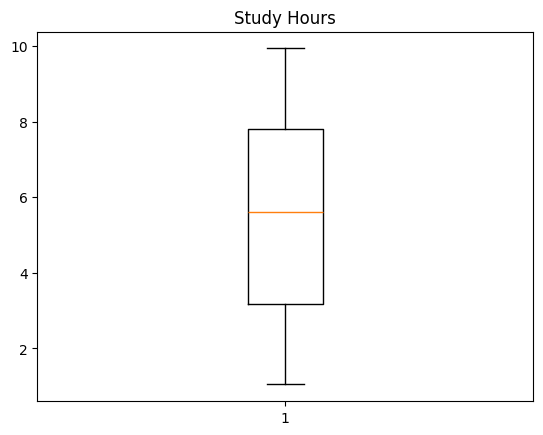

In [17]:
plt.boxplot(data['Study Hours'])
plt.title("Study Hours")
plt.show()

In [18]:
from numpy._core.defchararray import upper
data['Study Hours']=pd.to_numeric(data['Study Hours'],errors='coerce')
data['Previous Exam Score	']=pd.to_numeric(data['Previous Exam Score'],errors='coerce')
def outlier(col):
  Q1=data[col].quantile(0.25)
  Q3=data[col].quantile(0.75)
  IQR=Q3-Q1
  lower =Q1-1.5*IQR
  upper=Q3+1.5*IQR
  data[col]=data[col].clip(Lower,Upper)

  outlier('Study Hours')
  outlier('Previous Exam Score')

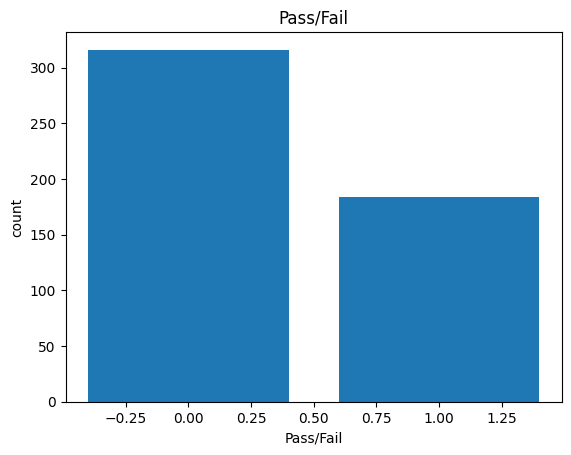

In [19]:
plt.bar(data['Pass/Fail'].value_counts().index ,data['Pass/Fail'].value_counts().values)
plt.title('Pass/Fail')
plt.xlabel('Pass/Fail')
plt.ylabel('count')
plt.show()

/var/folders/bk/rmcw2nx10jgcq7pkdzp55hwr0000gn/T/ipykernel_2021/1517770541.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=pass_or_fail.index,y=pass_or_fail.values,palette=['red','blue'])


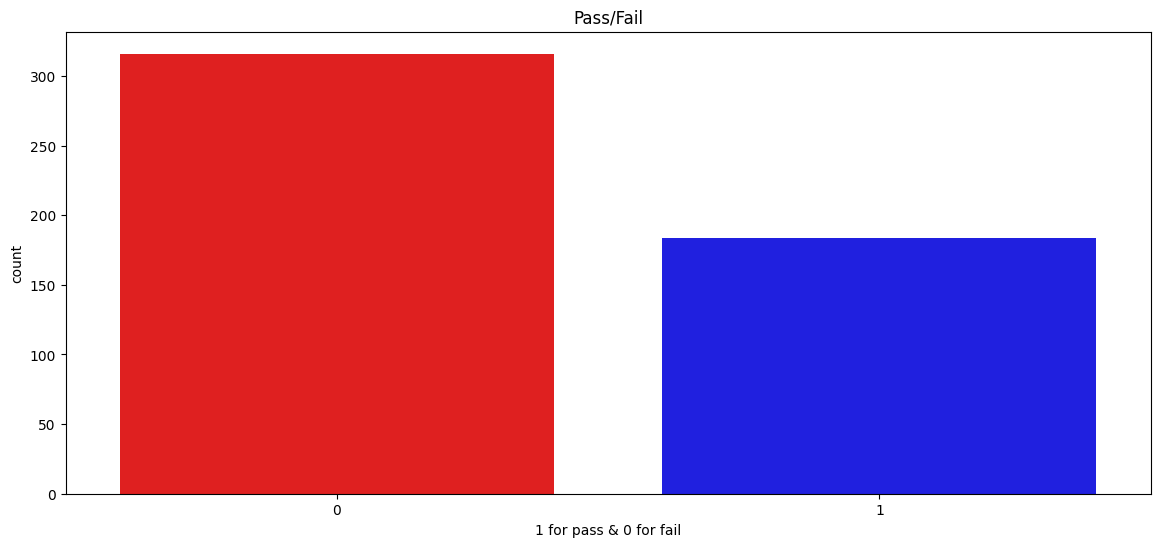

In [36]:
from numpy import poly
pass_or_fail = data['Pass/Fail'].value_counts()
plt.figure(figsize=(14,6))
sns.barplot(x=pass_or_fail.index,y=pass_or_fail.values,palette=['red','blue'])
plt.title('Pass/Fail')
plt.xlabel('1 for pass & 0 for fail')
plt.ylabel('count')
plt.show()

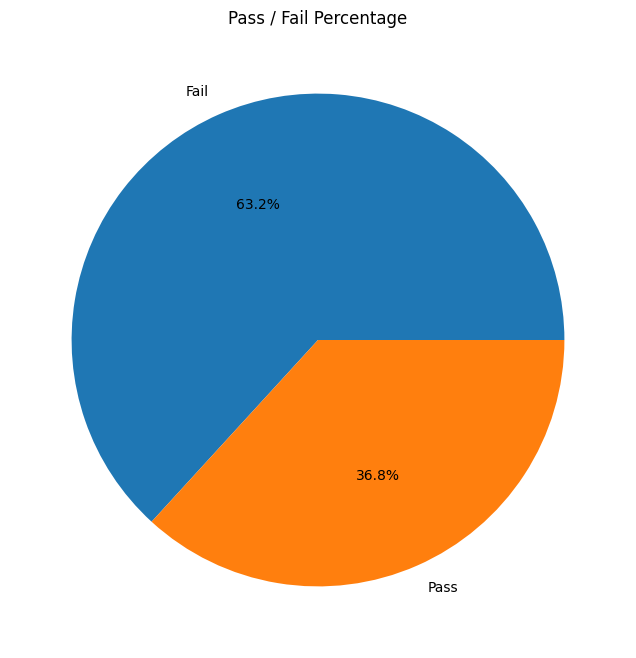

In [21]:
pass_counts = data['Pass/Fail'].value_counts()

plt.figure(figsize=(8,8))
plt.pie(
    pass_counts.values,
    labels=['Fail','Pass'],
    autopct='%1.1f%%'
)
plt.title('Pass / Fail Percentage')
plt.show()

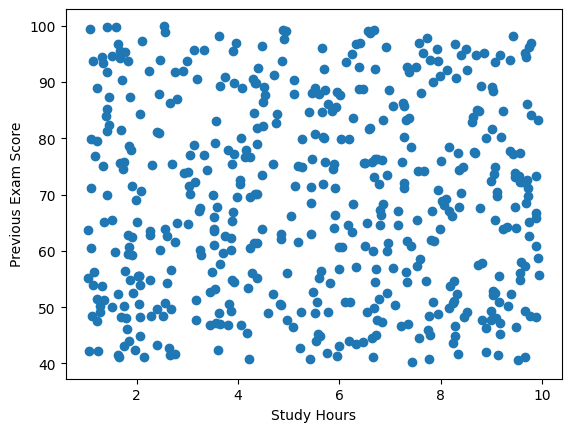

In [22]:
plt.scatter(data['Study Hours'], data['Previous Exam Score'])
plt.xlabel('Study Hours')
plt.ylabel('Previous Exam Score')
plt.show()

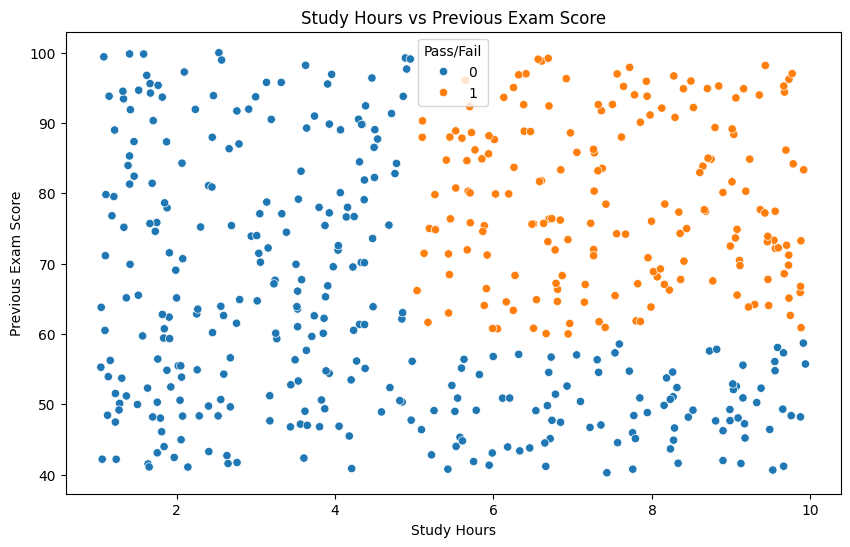

In [23]:
plt.figure(figsize=(10,6))
sns.scatterplot(
    x='Study Hours',
    y='Previous Exam Score',
    hue='Pass/Fail',
    data=data
)
plt.title('Study Hours vs Previous Exam Score')
plt.show()

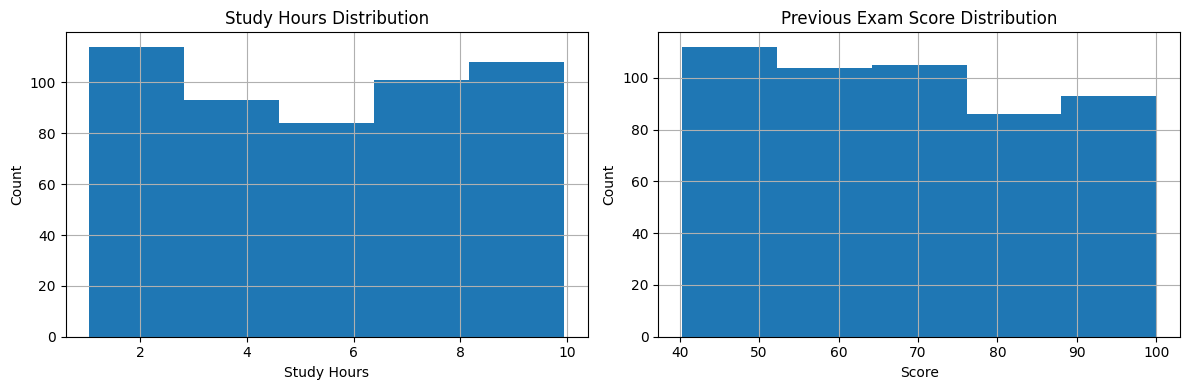

In [24]:
plt.figure(figsize=(12,4))

plt.subplot(1,2,1)
data['Study Hours'].hist(bins=5)
plt.title('Study Hours Distribution')
plt.xlabel('Study Hours')
plt.ylabel('Count')

plt.subplot(1,2,2)
data['Previous Exam Score'].hist(bins=5)
plt.title('Previous Exam Score Distribution')
plt.xlabel('Score')
plt.ylabel('Count')

plt.tight_layout()
plt.show()

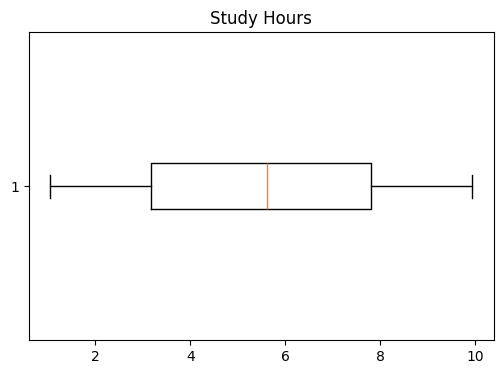

In [25]:
plt.figure(figsize=(6,4))
plt.boxplot(data['Study Hours'], vert=False)
plt.title('Study Hours')
plt.show()

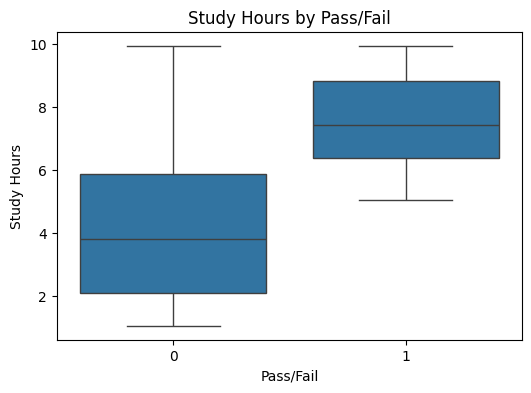

In [26]:
plt.figure(figsize=(6,4))
sns.boxplot(x='Pass/Fail', y='Study Hours', data=data)
plt.title('Study Hours by Pass/Fail')
plt.show()

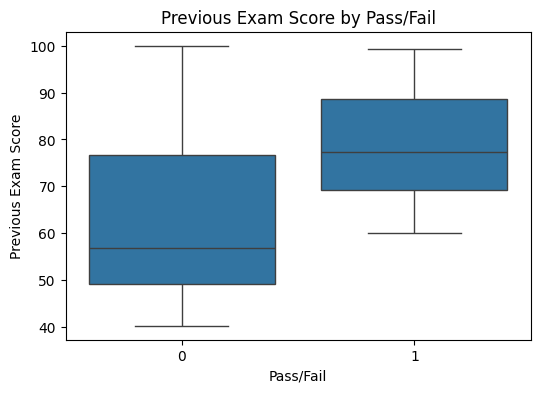

In [27]:
plt.figure(figsize=(6,4))
sns.boxplot(x='Pass/Fail', y='Previous Exam Score', data=data)
plt.title('Previous Exam Score by Pass/Fail')
plt.show()

/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/seaborn/utils.py:61: UserWarning: Glyph 9 (	) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/Users/rebuy/Library/Python/3.14/lib/python/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 9 (	) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


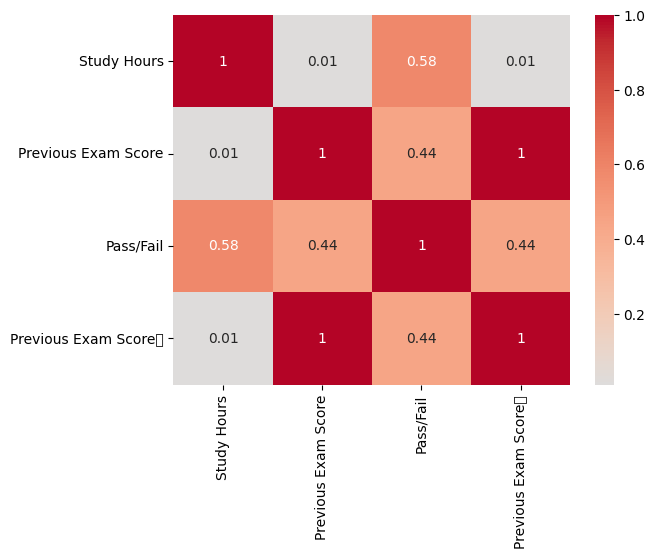

In [28]:
corr = data.corr()

sns.heatmap(corr, annot=True, cmap='coolwarm', center=0)
plt.show()

In [29]:
# Features & Target
X = data[['Study Hours', 'Previous Exam Score']]
y = data['Pass/Fail']

In [30]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [31]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

log_model = LogisticRegression()
log_model.fit(X_train_scaled, y_train)

y_pred = log_model.predict(X_test_scaled)

print("Logistic Regression Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Logistic Regression Accuracy: 0.86
              precision    recall  f1-score   support

           0       0.88      0.91      0.89        64
           1       0.82      0.78      0.80        36

    accuracy                           0.86       100
   macro avg       0.85      0.84      0.85       100
weighted avg       0.86      0.86      0.86       100



In [32]:
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train_scaled, y_train)

y_pred_knn = knn.predict(X_test_scaled)

print("KNN Accuracy:", accuracy_score(y_test, y_pred_knn))
print(classification_report(y_test, y_pred_knn))


KNN Accuracy: 0.96
              precision    recall  f1-score   support

           0       0.95      0.98      0.97        64
           1       0.97      0.92      0.94        36

    accuracy                           0.96       100
   macro avg       0.96      0.95      0.96       100
weighted avg       0.96      0.96      0.96       100



In [33]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))

Random Forest Accuracy: 0.99
              precision    recall  f1-score   support

           0       0.98      1.00      0.99        64
           1       1.00      0.97      0.99        36

    accuracy                           0.99       100
   macro avg       0.99      0.99      0.99       100
weighted avg       0.99      0.99      0.99       100



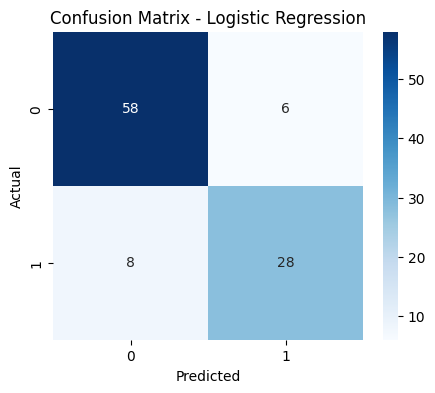

In [34]:
plt.figure(figsize=(5,4))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix - Logistic Regression")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()